First Five Records:
            Timestamp     1. Name    2. Gender      3. Age    \
0  9/17/2026 19:06:57  Priti Yadav        Female          19   
1  9/17/2026 19:36:36        Sapna        Female          18   
2  9/17/2026 19:37:30      Shreeom          Male          20   
3  9/17/2026 19:38:33     Sangeeta        Female          29   
4  9/17/2026 19:39:28       Shruti        Female          17   

    4. On average, how many hours do you study per day?    \
0                                          2-3 hours        
1                                         4-5 hours         
2                                          1-2 hours        
3                                            2 hours        
4                                                  3        

    5. How many days per week do you study?    \
0                                    3–4 days   
1                                    3–4 days   
2                                    5–6 days   
3                               

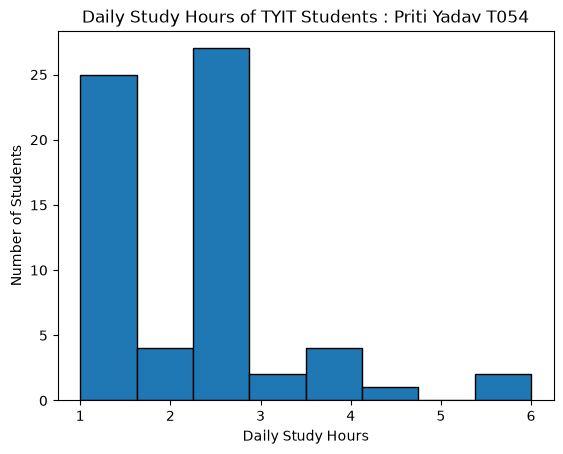


Observations:
1. The average daily study time is about 2.3 hours.
2. The median study time is 2.5 hours per day.


In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# 1. Load the survey data
df = pd.read_csv("A Survey on Daily Study Hrs.csv")

# 2. Display first five records
print("First Five Records:")
print(df.head())

# 3. Study hours column
col = df.columns[4]

# Convert study-hour responses into numerical values
def convert_hours(value):
    value = str(value)

    # Convert ranges into midpoint
    match = re.search(r'(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)', value)

    if match:
        a = float(match.group(1))
        b = float(match.group(2))
        return (a + b) / 2

    # Convert single numerical values
    match = re.search(r'\d+(?:\.\d+)?', value)

    if match:
        return float(match.group())

    return np.nan


df["Study Hours"] = df[col].apply(convert_hours)

# Remove missing values
study_hours = df["Study Hours"].dropna()

# 4. Display collected data
print("\nTotal Responses:", len(df))

# 5. Population and sample
print("\nPopulation: TYIT students")
print("Sample: Students who responded to the survey")

# 6. Sampling technique
print("Sampling Technique: Simple Random Sampling")

# 7. Numerical variables
print("\nNumerical Variables:")
print("Age, Study Hours")

# 8. Categorical variables
print("\nCategorical Variables:")
print("Gender, Days per Week, Study Schedule, Study Location")

# 9 & 10. Calculate statistics
sample_size = len(study_hours)
sample_mean = study_hours.mean()
sample_median = study_hours.median()
sample_std = study_hours.std()

print("\nStudy Hours Statistics:")
print("Sample Size:", sample_size)
print("Mean:", round(sample_mean, 2), "hours")
print("Median:", round(sample_median, 2), "hours")
print("Standard Deviation:", round(sample_std, 2), "hours")

# Display study hours in compact format
print("\nStudy Hours Data:")
for i in range(0, len(study_hours), 10):
    print(" | ".join(
        f"{j+1}:{study_hours.iloc[j]:.1f}"
        for j in range(i, min(i+10, len(study_hours)))
    ))

# 11. Chart
plt.hist(study_hours, bins=8, edgecolor="black")
plt.xlabel("Daily Study Hours")
plt.ylabel("Number of Students")
plt.title("Daily Study Hours of TYIT Students : Priti Yadav T054")
plt.show()

# 12. Observations
print("\nObservations:")
print("1. The average daily study time is about",
      round(sample_mean, 2), "hours.")
print("2. The median study time is",
      round(sample_median, 2), "hours per day.")


First 10 Sample Means:
Sample 1: 2.25
Sample 2: 2.18
Sample 3: 2.45
Sample 4: 2.40
Sample 5: 2.32
Sample 6: 2.30
Sample 7: 2.42
Sample 8: 2.53
Sample 9: 2.27
Sample 10: 2.22

Sampling Distribution:
Number of Samples: 100
Sample Size: 30
Mean of Sample Means: 2.3
Standard Deviation of Sample Means: 0.13


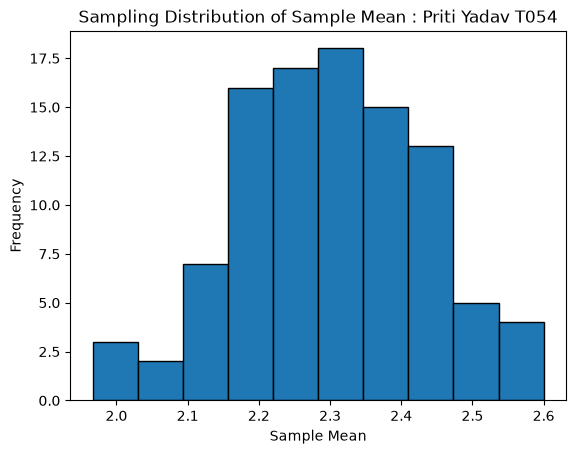


Comparison:
Original Sample Mean: 2.28
Mean of Sampling Distribution: 2.3

Standard Error: 0.18

Central Limit Theorem:
The sampling distribution of the sample mean
becomes approximately normal as the sample size increases.

Estimated Population Mean: 2.28 hours


In [11]:
# PART B: Sampling Distribution and CLT

# Select numerical variable
data = study_hours.to_numpy()

# 14. Select sample size
sample_size = 30

# 16. Number of repetitions
num_samples = 100

# Set random seed
np.random.seed(42)

# 17. Store sample means
sample_means = []

for i in range(num_samples):

    # Random sample of 30 observations
    sample = np.random.choice(
        data,
        size=sample_size,
        replace=False
    )

    # Calculate sample mean
    sample_mean = np.mean(sample)
    sample_means.append(sample_mean)

sample_means = np.array(sample_means)

# 18. Display first 10 sample means
print("\nFirst 10 Sample Means:")

for i, mean in enumerate(sample_means[:10], start=1):
    print(f"Sample {i}: {mean:.2f}")

# 19. Mean of all sample means
mean_sampling_distribution = sample_means.mean()

# 20. Standard deviation of sample means
std_sampling_distribution = sample_means.std(ddof=1)

print("\nSampling Distribution:")
print("Number of Samples:", num_samples)
print("Sample Size:", sample_size)
print("Mean of Sample Means:",
      round(mean_sampling_distribution, 2))
print("Standard Deviation of Sample Means:",
      round(std_sampling_distribution, 2))

# 21. Histogram
plt.hist(sample_means, bins=10, edgecolor="black")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.title("Sampling Distribution of Sample Mean : Priti Yadav T054")
plt.show()

# 22 & 23. Comparison
print("\nComparison:")
print("Original Sample Mean:",
      round(sample_mean, 2))
print("Mean of Sampling Distribution:",
      round(mean_sampling_distribution, 2))

# 25. Standard Error
standard_error = sample_std / np.sqrt(sample_size)

print("\nStandard Error:",
      round(standard_error, 2))

# 26. CLT explanation
print("\nCentral Limit Theorem:")
print("The sampling distribution of the sample mean")
print("becomes approximately normal as the sample size increases.")

# 27. Population mean estimation
print("\nEstimated Population Mean:",
      round(sample_mean, 2), "hours")
